## Plot Results

This notebook is intended to generate plots and videos for the GP-MPC controller when you want to compare multiple log files against each other.

In [323]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd

# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [324]:
# Define some matplotlib parameters
# Use LaTeX for rendering text in plots
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

## Results: Failure Detection vs. No Failure Detection

Here we want to motivate the use of failure detection in our pipeline.

In [325]:
# Load the necessary bags

# Create Logger object (needed to load data)
logger = Logger()

# Set names of the different logs
filename1 = "2024-10-20_18-14-08" # MPCC w/o Failure Detection
filename2 = None # MPCC w/ Failure Detection


filenames = [filename1, filename2]

# Load the pandas dataframes
df_list = []
for filename in filenames:
    df_list.append(logger.load_log(filename))

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-20_18-14-08
Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-20_23-20-53


Let's compare the cumulative closed-loop cost of the three configurations.

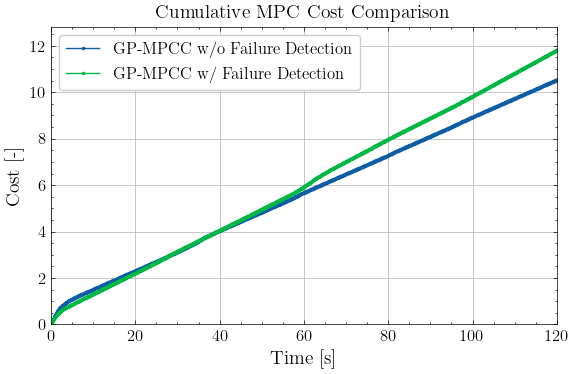

In [326]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Iterate through each dataframe and plot the cumulative cost
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in 'mpc_cost' or 'Timestamp'
        df_clean = df[['Timestamp', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Compute cumulative cost
        df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the cumulative cost with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['cumulative_cost'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Cost [-]')
plt.title('Cumulative MPC Cost Comparison')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=df_clean['cumulative_cost'].max()+ 1)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case1_cumulative_cost.svg", format="svg")
plt.savefig("case2/case1_cumulative_cost.pdf", format="pdf")


In [327]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 80

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Initialize an empty list to store the results
results = []

# Iterate through each dataframe and compute the required metrics
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in the relevant columns
        df_clean = df[['Timestamp', 'tracking_error', 'attitude_error', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]
        
        # Calculate the metrics
        mean_tracking_error = df_clean['tracking_error'].mean()
        mean_attitude_error = df_clean['attitude_error'].mean()
        cumulative_mpc_cost = df_clean['mpc_cost'].cumsum().iloc[-1]  # Get final cumulative MPC cost
        
        # Append the results for this configuration
        results.append({
            'Configuration': labels[i],
            'Mean Tracking Error': mean_tracking_error,
            'Mean Attitude Error': mean_attitude_error,
            'Cumulative MPC Cost': cumulative_mpc_cost
        })

# Convert the results to a pandas DataFrame
comparison_df = pd.DataFrame(results)

# Display the table
print(comparison_df)

# Optionally, display the DataFrame as a LaTeX table
latex_table = comparison_df.to_latex(index=False, float_format="%.3f")
print(latex_table)

                   Configuration  Mean Tracking Error  Mean Attitude Error  \
0  GP-MPCC w/o Failure Detection             0.024209             3.367289   
1   GP-MPCC w/ Failure Detection             0.034159             8.924586   

     Cumulative MPC Cost  
0   [[7.29094539717169]]  
1  [[7.982995774821757]]  
\begin{tabular}{lrrl}
\toprule
Configuration & Mean Tracking Error & Mean Attitude Error & Cumulative MPC Cost \\
\midrule
GP-MPCC w/o Failure Detection & 0.024 & 3.367 & [[7.2909454]] \\
GP-MPCC w/ Failure Detection & 0.034 & 8.925 & [[7.98299577]] \\
\bottomrule
\end{tabular}



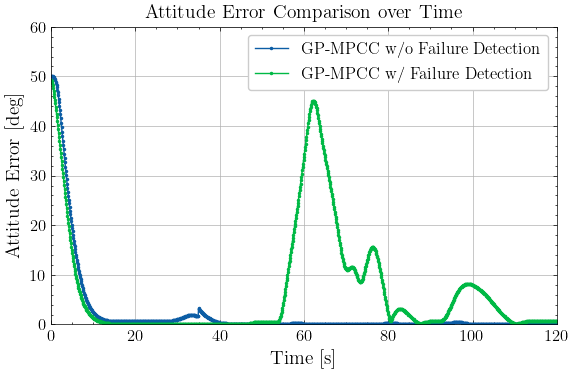

In [328]:
# %% [markdown]
# ## Compare Attitude Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Iterate through each dataframe and plot the attitude error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'attitude_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'attitude_error']].dropna()

        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the attitude error with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['attitude_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Attitude Error [deg]')
plt.title('Attitude Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=60)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case1_attitude_error.svg", format="svg")
plt.savefig("case2/case1_attitude_error.pdf", format="pdf")


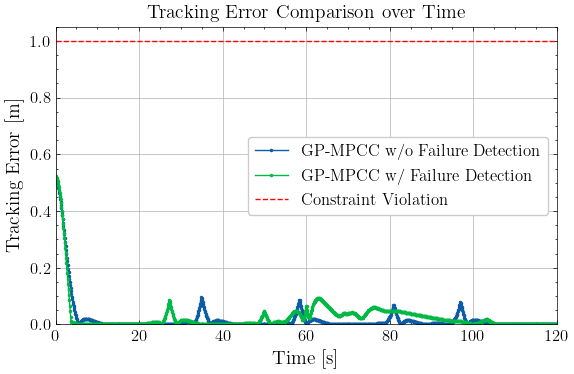

In [329]:
# %% [markdown]
# ## Compare Tracking Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Iterate through each dataframe and plot the tracking error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'tracking_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'tracking_error']].dropna()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the tracking error with the same style as your attitude error plot
        plt.plot(df_clean['Timestamp'], df_clean['tracking_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=1, color='red', linestyle='--', label='Constraint Violation')

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Tracking Error [m]')
plt.title('Tracking Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim((0, 1.05))

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case1_tracking_error.svg", format="svg")
plt.savefig("case2/case1_tracking_error.pdf", format="pdf")

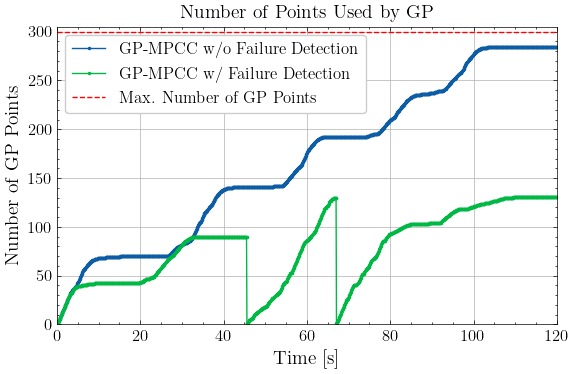

In [330]:
# %% [markdown]
# ## Compare Tracking Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['GP-MPCC w/o Failure Detection', 'GP-MPCC w/ Failure Detection']

# Iterate through each dataframe and plot the tracking error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'tracking_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'n_points_GP']].dropna()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the tracking error with the same style as your attitude error plot
        plt.plot(df_clean['Timestamp'], df_clean['n_points_GP'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=300, color='red', linestyle='--', label='Max. Number of GP Points')

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Number of GP Points')
plt.title('Number of Points Used by GP')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim((0,305))

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case2/case2_n_points_GP.svg", format="svg")
plt.savefig("case2/case2_n_points_GP.pdf", format="pdf")

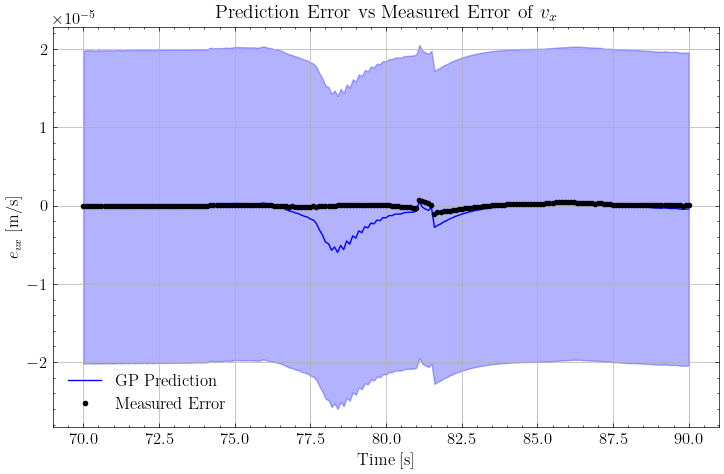

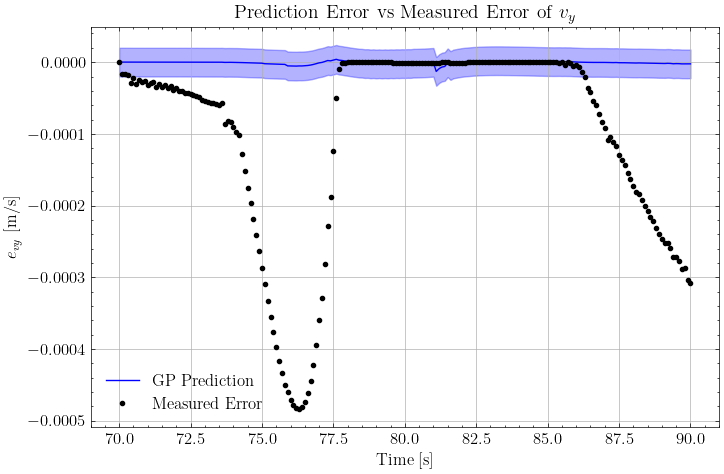

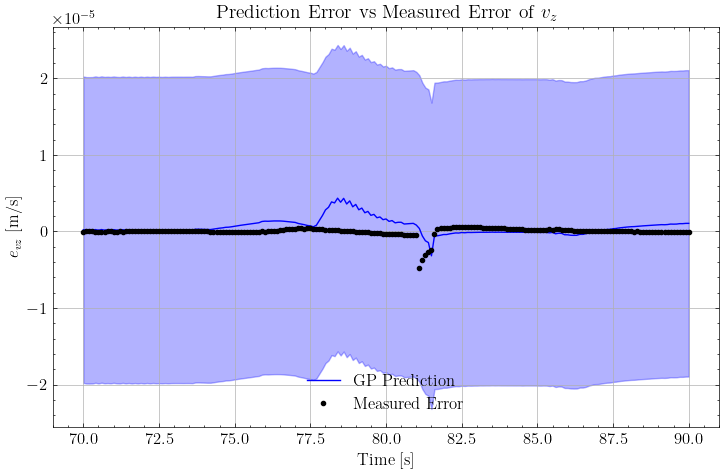

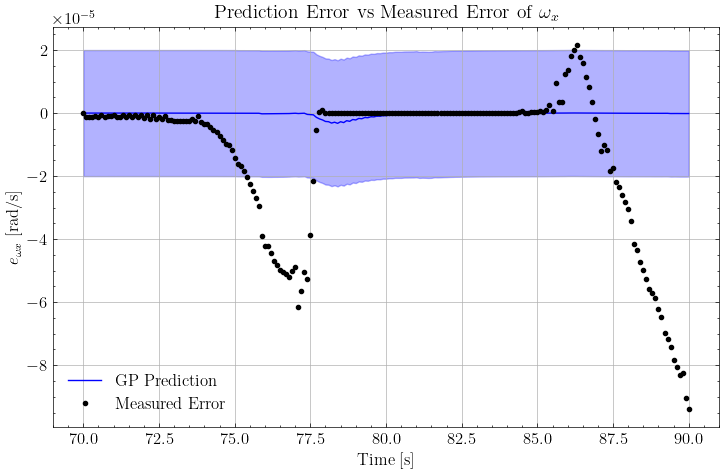

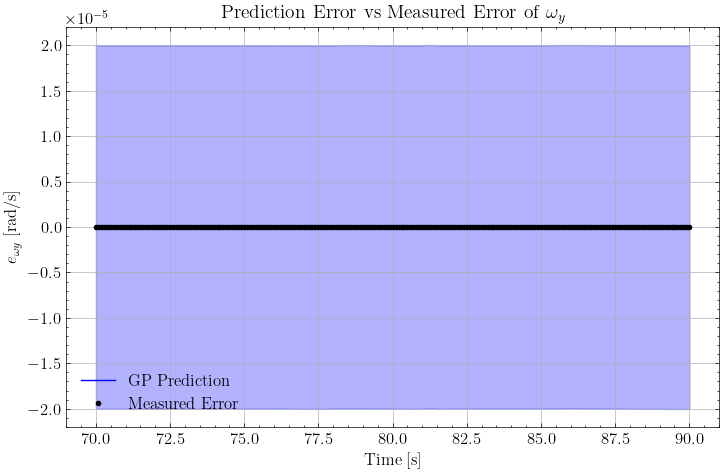

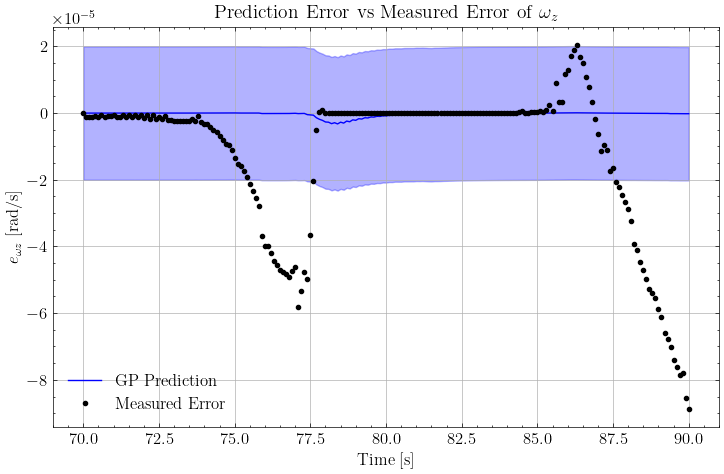

In [331]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 70
END_TIME = 90

def plot_gp_component(df_clean, index, title, ylabel):
    """
    Plots the GP prediction and confidence interval for a specific component.
    """

    # Extract the specific component for each DataFrame column
    gp_pred_component = df_clean['gp_pred'].apply(lambda x: x[index])
    gp_GT_component = df_clean['gp_GT'].apply(lambda x: x[index])
    gp_upper_component = df_clean['gp_upper'].apply(lambda x: x[index])
    gp_lower_component = df_clean['gp_lower'].apply(lambda x: x[index])

    # Plot
    plt.figure(figsize=(7.5, 5))
    plt.plot(df_clean['Timestamp'], gp_pred_component, "b", label="GP Prediction")  # Mean prediction in blue
    plt.fill_between(df_clean['Timestamp'], gp_lower_component, gp_upper_component, alpha=0.3, color='blue')  # Confidence interval
    plt.plot(df_clean['Timestamp'], gp_GT_component, "k.", label="Measured Error")  # Ground truth data in black

    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'

df_clean = df_list[0][['Timestamp', 'gp_pred', 'gp_GT', 'gp_upper', 'gp_lower']].dropna()

# Filter based on start_time and end_time if provideds
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]


# Define the components and titles for each component
components = [
    (0, r"Prediction Error vs Measured Error of $v_{x}$", r"$e_{vx}$ [m/s]"),
    (1, r"Prediction Error vs Measured Error of $v_{y}$", r"$e_{vy}$ [m/s]"),
    (2, r"Prediction Error vs Measured Error of $v_{z}$", r"$e_{vz}$ [m/s]"),
    (3, r"Prediction Error vs Measured Error of $\omega_{x}$", r"$e_{\omega x}$ [rad/s]"),
    (4, r"Prediction Error vs Measured Error of $\omega_{y}$", r"$e_{\omega y}$ [rad/s]"),
    (5, r"Prediction Error vs Measured Error of $\omega_{z}$", r"$e_{\omega z}$ [rad/s]"),
]

# Loop through each component and plot
for index, title, ylabel in components:
    plot_gp_component(df_clean, index, title, ylabel)

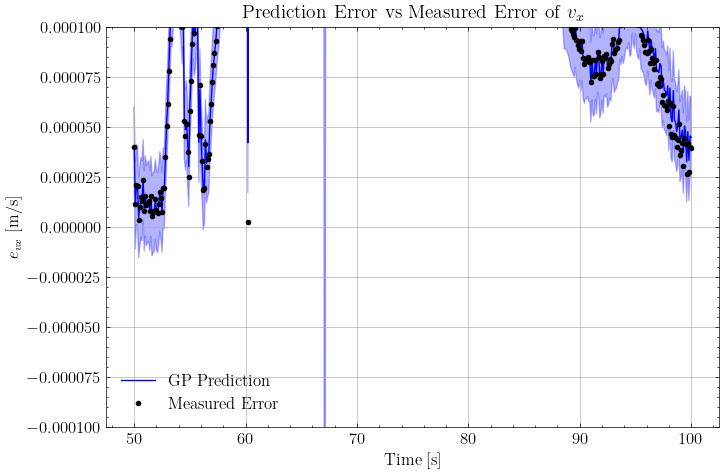

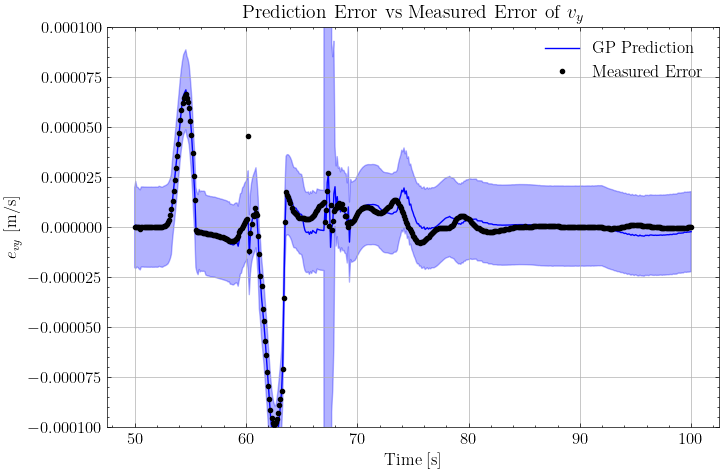

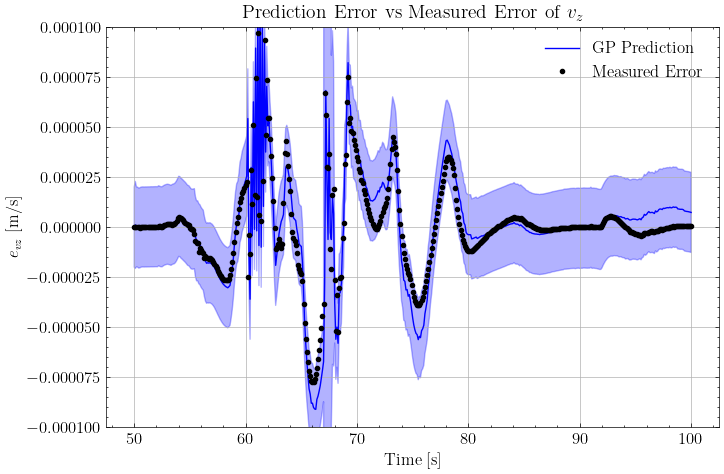

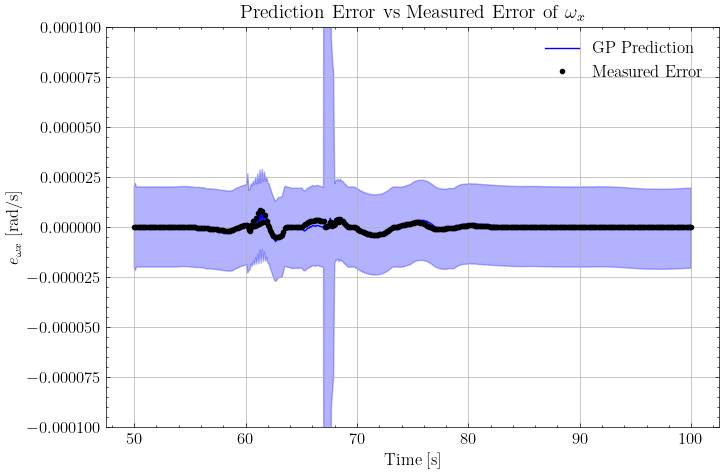

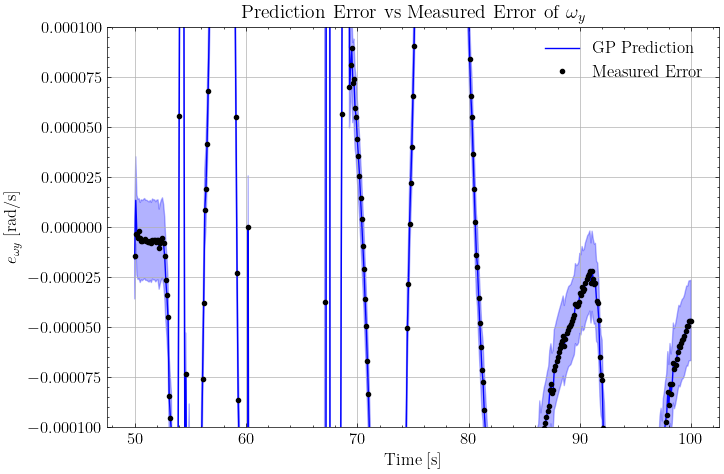

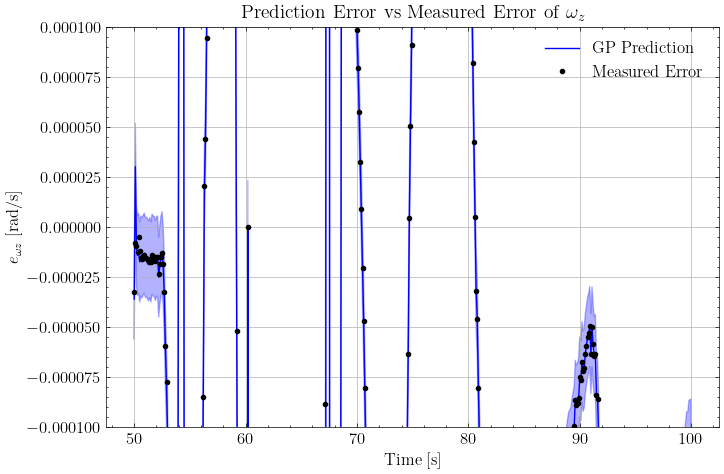

In [332]:
# Assuming your DataFrame is named df
# NOTE: Specify paramters here if you want
START_TIME = 50
END_TIME = 100

def plot_gp_component(df_clean, index, title, ylabel):
    """
    Plots the GP prediction and confidence interval for a specific component.
    """

    # Extract the specific component for each DataFrame column
    gp_pred_component = df_clean['gp_pred'].apply(lambda x: x[index])
    gp_GT_component = df_clean['gp_GT'].apply(lambda x: x[index])
    gp_upper_component = df_clean['gp_upper'].apply(lambda x: x[index])
    gp_lower_component = df_clean['gp_lower'].apply(lambda x: x[index])

    # Plot
    plt.figure(figsize=(7.5, 5))
    plt.plot(df_clean['Timestamp'], gp_pred_component, "b", label="GP Prediction")  # Mean prediction in blue
    plt.fill_between(df_clean['Timestamp'], gp_lower_component, gp_upper_component, alpha=0.3, color='blue')  # Confidence interval
    plt.plot(df_clean['Timestamp'], gp_GT_component, "k.", label="Measured Error")  # Ground truth data in black

    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=12)
    plt.ylim((-0.001, 0.001))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

# Drop rows with NaNs in 'e_gp', 'e_nom', or 'Timestamp'

df_clean = df_list[1][['Timestamp', 'gp_pred', 'gp_GT', 'gp_upper', 'gp_lower']].dropna()

# Filter based on start_time and end_time if provideds
if START_TIME is not None:
    df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
if END_TIME is not None:
    if END_TIME > (max_timestamp := df_clean['Timestamp'].max()):
        warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
    else:
        df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]


# Define the components and titles for each component
components = [
    (0, r"Prediction Error vs Measured Error of $v_{x}$", r"$e_{vx}$ [m/s]"),
    (1, r"Prediction Error vs Measured Error of $v_{y}$", r"$e_{vy}$ [m/s]"),
    (2, r"Prediction Error vs Measured Error of $v_{z}$", r"$e_{vz}$ [m/s]"),
    (3, r"Prediction Error vs Measured Error of $\omega_{x}$", r"$e_{\omega x}$ [rad/s]"),
    (4, r"Prediction Error vs Measured Error of $\omega_{y}$", r"$e_{\omega y}$ [rad/s]"),
    (5, r"Prediction Error vs Measured Error of $\omega_{z}$", r"$e_{\omega z}$ [rad/s]"),
]

# Loop through each component and plot
for index, title, ylabel in components:
    plot_gp_component(df_clean, index, title, ylabel)

In [333]:
df_clean_video = df[0][['Timestamp', 'frames']].dropna()[1:].reset_index(drop=True)
print(df_clean_video)

KeyError: 0

In [ ]:
# Load the rest of the data
df_clean = df[['Timestamp', 'n_points_GP', 'e_gp', 'e_nom', 'tracking_error', 'attitude_error', 'u_demanded', 'u_actual', 'mpc_cost', 'velocity']].dropna().reset_index(drop=True)
df_clean['mpc_cost'] += 5e-2 * 0.2
df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
print(df_clean)

In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
import numpy as np

# Example DataFrame with video frames and timestamps
timestamps = df_clean_video['Timestamp'].values
n_points_GP = df_clean['n_points_GP'].values
e_gp = df_clean['e_gp'].values
e_nom = df_clean['e_nom'].values
tracking_error = df_clean['tracking_error'].values
attitude_error = df_clean['attitude_error'].values
u_demanded = df_clean['u_demanded'].values
u_actual = df_clean['u_actual'].values
mpc_cost = df_clean['mpc_cost'].values
cumulative_cost = df_clean['cumulative_cost'].values
velocity = df_clean['velocity'].values

# Extract data for a specific thruster
thruster_idx = 0
u_demanded_i = np.array([u[thruster_idx] for u in u_demanded])
u_actual_i = np.array([u[thruster_idx] for u in u_actual])

# Create the figure and GridSpec layout
fig = plt.figure(figsize=(19.2, 10.8), dpi=200)
gs = GridSpec(14, 25)  # Create a grid with 6 rows and 6 columns

# Subplot for video frames (large top-left area)
ax_video = fig.add_subplot(gs[0:9, 0:16])  # Spanning 9 rows and 16 columns (more horizontal space)
ax_video.axis('off')  # Remove axes for the video

# Two smaller plots stacked to the right of the video
ax_plot_right_top = fig.add_subplot(gs[0:4, 17:25])  # First small plot to the right of the video
ax_plot_right_top.set_title("Prediction Error")

ax_plot_right_bottom = fig.add_subplot(gs[5:9, 17:25])  # Second small plot to the right of the video
ax_plot_right_bottom.set_title("Number of Training Points in GP")

# Two plots side by side below the video (bottom left)
ax_bottom_left_1 = fig.add_subplot(gs[10:14, 0:7])  # First plot below the video
ax_bottom_left_1.set_title("Lateral Tracking Error")

ax_bottom_left_2 = fig.add_subplot(gs[10:14, 9:16])  # Second plot below the video
ax_bottom_left_2.set_title("Attitude Error")

# One plot in the bottom right corner (below the stacked plots)
ax_bottom_right = fig.add_subplot(gs[10:14, 17:25])  # Plot in the bottom right corner
ax_bottom_right.set_title(f"Demanded vs. Actual Thrust of Thruster {thruster_idx}")


def get_sliding_window_idx(frame, window_size):
    return max(0, frame - window_size), min(frame + 1, len(df_clean_video))


# Update function for each frame
def update(frame):
    # Get the current video frame from the DataFrame
    video_frame = df_clean_video['frames'].iloc[frame]

    # Update video subplot
    ax_video.clear()
    ax_video.axis('off')  # Hide axes for the video
    if video_frame is not None:
        ax_video.imshow(video_frame)  # Display video frame

    # Update the right top plot
    start_idx, end_idx = get_sliding_window_idx(frame, 200)
    ax_plot_right_top.clear()
    ax_plot_right_top.set_title("Prediction Error")
    ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_gp[start_idx:end_idx], lw=2, label=r'$e_{\text{GP}}$')
    ax_plot_right_top.plot(timestamps[start_idx:end_idx], e_nom[start_idx:end_idx], lw=2, label=r'$e_{\text{nom}}$')
    ax_plot_right_top.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_plot_right_top.set_xlabel("Time [s]")
    ax_plot_right_top.set_ylabel(r"Error $l_2$ norm")
    ax_plot_right_top.set_ylim(bottom=0)
    ax_plot_right_top.legend(loc='best')

    # Update the right bottom plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_plot_right_bottom.clear()
    ax_plot_right_bottom.set_title("Number of Training Points in GP")
    ax_plot_right_bottom.plot(timestamps[start_idx:end_idx], n_points_GP[start_idx:end_idx], lw=2, marker='.')
    ax_plot_right_bottom.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_plot_right_bottom.set_xlabel("Time [s]")
    ax_plot_right_bottom.set_ylabel("# GP points")
    ax_bottom_right.set_ylim((0,300))

    # Update bottom left plot 1
    start_idx, end_idx = get_sliding_window_idx(frame, 100)
    ax_bottom_left_1.clear()
    ax_bottom_left_1.set_title("Lateral Tracking Error")
    ax_bottom_left_1.plot(timestamps[start_idx:end_idx], tracking_error[start_idx:end_idx], lw=2)
    ax_bottom_left_1.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_left_1.set_xlabel("Time [s]")
    ax_bottom_left_1.set_ylabel("Error [m]")
    ax_bottom_left_1.set_ylim(bottom=0)

    # Update bottom left plot 2
    ax_bottom_left_2.clear()
    ax_bottom_left_2.set_title("Velocity")
    ax_bottom_left_2.plot(timestamps[start_idx:end_idx], velocity[start_idx:end_idx], lw=2)
    ax_bottom_left_2.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_left_2.set_xlabel("Time [s]")
    ax_bottom_left_2.set_ylabel("Velocity [m/s]")
    ax_bottom_left_2.set_ylim(bottom=0, top= 0.26)
    ax_bottom_left_2.axhline(y=0.25, color='red', linestyle='--', label='Upper Bound')
    ax_bottom_left_2.legend(loc='best')

    # Update bottom right plot
    start_idx, end_idx = get_sliding_window_idx(frame, 500)
    ax_bottom_right.clear()
    ax_bottom_right.set_title(f"Cumulative cost")
    ax_bottom_right.plot(timestamps[start_idx:end_idx], cumulative_cost[start_idx:end_idx], lw=2)
    ax_bottom_right.set_xlim(timestamps[start_idx], timestamps[end_idx])
    ax_bottom_right.set_xlabel("Time [s]")
    ax_bottom_right.set_ylabel("Cost [-]")
    ax_bottom_right.set_ylim(bottom=0)
    ax_plot_right_top.legend(loc='best')

# Create the animation using FuncAnimation
ani = FuncAnimation(fig, update, frames=len(df_clean_video)-1, repeat=False)

# Save the animation as a video file
ani.save('output_video.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

print("Video saved as output_video.mp4")